# ML Data Preprocessing Pipeline Demo

This notebook demonstrates the ML Data Preprocessing pipeline for DEM, climate variables, and rainfall data. It allows you to run each component and control the parameters.

## 0. Setup and Imports

In [1]:
from pprint import pprint
import os
import numpy as np
import pandas as pd

from ML_Data_Preprocessing import config
from ML_Data_Preprocessing.extract_station_metadata import get_station_metadata
from ML_Data_Preprocessing.build_dem_patches import DEMPatchBuilder
from ML_Data_Preprocessing.utils import discover_station_months
from ML_Data_Preprocessing.build_reanalysis_features import ReanalysisFeatureBuilder
from ML_Data_Preprocessing.assemble_training_data import TrainingDataAssembler

In [2]:
cfg = config.get_config()
pprint(cfg)
print(f"To change any of these, edit the {config.__file__} file")

{'dem_patch_config': {'local': {'km_per_cell': 2, 'patch_size': 3},
                      'regional': {'km_per_cell': 8, 'patch_size': 3}},
 'paths': {'dem': 'raw_data/DEM/DEM_Tut1.tif',
           'output_dir': 'ML_Data_Preprocessing/output',
           'rainfall_data_dir': 'Process_Rainfall_Data/output/monthly_rainfall',
           'reanalysis_dir': 'raw_data/climate_variables',
           'station_metadata': 'raw_data/station_locations.csv'},
 'rainfall_outlier_threshold': 3.0,
 'random_seed': 42,
 'reanalysis_patch_size': 3,
 'reanalysis_variables': ['air_temp_diff_1000_500',
                          'air_2m',
                          'hgt_1000',
                          'hgt_500',
                          'omega_500',
                          'pottmp_diff_1000_500',
                          'pottmp_diff_1000_850',
                          'pr_wtr',
                          'shum_700',
                          'shum_925',
                          'zon_moist_700',
        

In [3]:
# Show output directory
output_dir = cfg['paths']['output_dir']
print(output_dir)


ML_Data_Preprocessing/output


In [4]:
# Load the raw station metadata
metadata_dict = get_station_metadata(config.STATION_METADATA_PATH)
print(f"Loaded raw metadata with {len(metadata_dict)} rows")

# Display a sample station
metadata_dict['poloa_UH']

Successfully loaded station metadata from raw_data/station_locations.csv
Found 26 stations
Loaded raw metadata with 26 rows


{'latitude': -14.31958056,
 'longitude': -170.8306889,
 'Organization': 'UH',
 'elev_ft': 479,
 'elev_src': 'DEM',
 'start_yr': 2019,
 'end_yr': 2024,
 'range': 5,
 'station_id': 1311.0,
 'source': 'HCDP',
 'source_unit': 'mm',
 'source_freq': '15min'}

In [5]:
# Discover which station-month tuples have non-empty rainfall data 
station_metadata_path = "raw_data/station_locations.csv"
station_metadata = get_station_metadata(station_metadata_path)
station_months_map = discover_station_months(station_metadata)

# Print the station_months_map
pprint(f"Months with data for poloa_UH: {station_months_map['poloa_UH']}")

Successfully loaded station metadata from raw_data/station_locations.csv
Found 26 stations
('Months with data for poloa_UH: [(2019, 7), (2019, 8), (2019, 9), (2019, 10), '
 '(2019, 11), (2019, 12), (2020, 1), (2020, 2), (2020, 3), (2020, 4), (2020, '
 '5), (2020, 6), (2020, 7), (2020, 8), (2020, 9), (2020, 10), (2020, 11), '
 '(2020, 12), (2021, 1), (2021, 2), (2021, 3), (2021, 4), (2021, 5), (2021, '
 '6), (2021, 7), (2021, 8), (2021, 9), (2021, 10), (2021, 11), (2021, 12), '
 '(2022, 1), (2022, 2), (2022, 3), (2022, 4), (2022, 5), (2022, 6), (2022, 7), '
 '(2022, 8), (2022, 9), (2022, 10), (2022, 11), (2022, 12), (2023, 1), (2023, '
 '2), (2023, 3), (2023, 4), (2023, 5), (2023, 6), (2023, 7), (2023, 8), (2023, '
 '9), (2023, 10), (2023, 11), (2023, 12), (2024, 1), (2024, 2), (2024, 3), '
 '(2024, 4), (2024, 5), (2024, 6), (2024, 7), (2024, 8), (2024, 9), (2024, '
 '11), (2024, 12)]')


In [6]:
# Initialize the DEM patch builder
dem_builder = DEMPatchBuilder()

# Build patches for all stations
dem_patches = dem_builder.build_patches_for_stations()

Successfully loaded DEM from raw_data/DEM/DEM_Tut1.tif
DEM shape: (1562, 3256)
Bounds: BoundingBox(left=-170.847006549233, bottom=-14.374207000544647, right=-170.54552507619297, top=-14.229577374964647)
Pixel size: 9.259259000000408e-05° x 9.259259000000023e-05°
Successfully loaded station metadata from raw_data/station_locations.csv
Found 26 stations
Building DEM patches for station: poloa_UH
Interpolated DEM (shape (3, 3)):
[[136.52664 136.52664 136.52664]
 [136.52664 182.71094 232.32812]
 [136.52664 136.52664 136.52664]]
Applied edge padding for block-mean: top=1, bottom=1, left=1, right=1
Block-mean averaged DEM (shape (3, 3)):
[[136.52658 120.77589 132.07578]
 [116.34363 138.39673 190.67278]
 [136.52658 129.58316 128.50154]]
Interpolated DEM (shape (3, 3)):
[[137.01425 137.01425 137.01425]
 [137.01425 150.9011  352.24838]
 [137.01425 137.01425 137.01425]]
Applied edge padding for block-mean: top=0, bottom=1, left=0, right=0
Block-mean averaged DEM (shape (3, 3)):
[[137.01389 137.0

{'local': array([[136.52664, 136.52664, 136.52664],
       [136.52664, 182.71094, 232.32812],
       [136.52664, 136.52664, 136.52664]], dtype=float32),
 'regional': array([[137.01425, 137.01425, 137.01425],
       [137.01425, 150.9011 , 352.24838],
       [137.01425, 137.01425, 137.01425]], dtype=float32)}


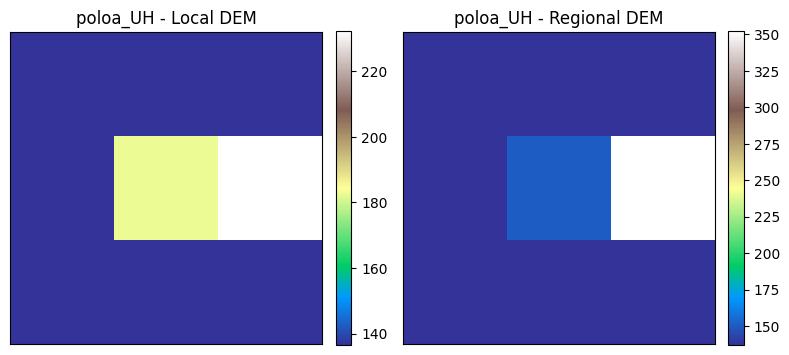

In [7]:
# Print example patches for poloa_UH
pprint(dem_patches['poloa_UH'])

# Visualize patches
dem_builder.visualize_patches(dem_patches, 'poloa_UH')

In [8]:
# Define output directory for DEM patches
dem_output_dir = output_dir +"/dem_npz"

# Export patches to NPZ file
save_path = dem_builder.export_all_dem_npz_standardized(
    dem_patches, station_months_map, dem_output_dir,
    filename="dem_patches_all_standardized.npz"
)

print(f"Saved standardized DEM NPZ to {save_path}")

Saved standardized DEM NPZ to ML_Data_Preprocessing/output/dem_npz/dem_patches_all_standardized.npz


# Reanalysis Features Builder


In [9]:
# Set output directory for reanalysis features
npz_dir = "ML_Data_Preprocessing/output/reanalysis_npz"
if not os.path.exists(npz_dir):
   os.makedirs(npz_dir, exist_ok=False)

# Initialize builder and process all configured variables
feature_builder = ReanalysisFeatureBuilder()

# Only process if the raw features NPZ doesn't exist
if not os.path.exists(npz_dir + "/reanalysis_features_all.npz"):
    print("Processing climate variables...")
    ok = feature_builder.process_all_variables()
    if not ok:
        print("Warning: some variables failed to process")

    # Build features for the discovered station-months only
    print("Building station-month reanalysis patches...")
    all_features = feature_builder.build_features_for_all_stations_with_map(
        station_metadata, station_months_map
    )
    raw_features_path = feature_builder.export_all_features_npz(
        all_features,
        npz_dir,
        filename="reanalysis_features_all.npz"
    )
    print(f"Saved raw reanalysis NPZ to: {raw_features_path}")

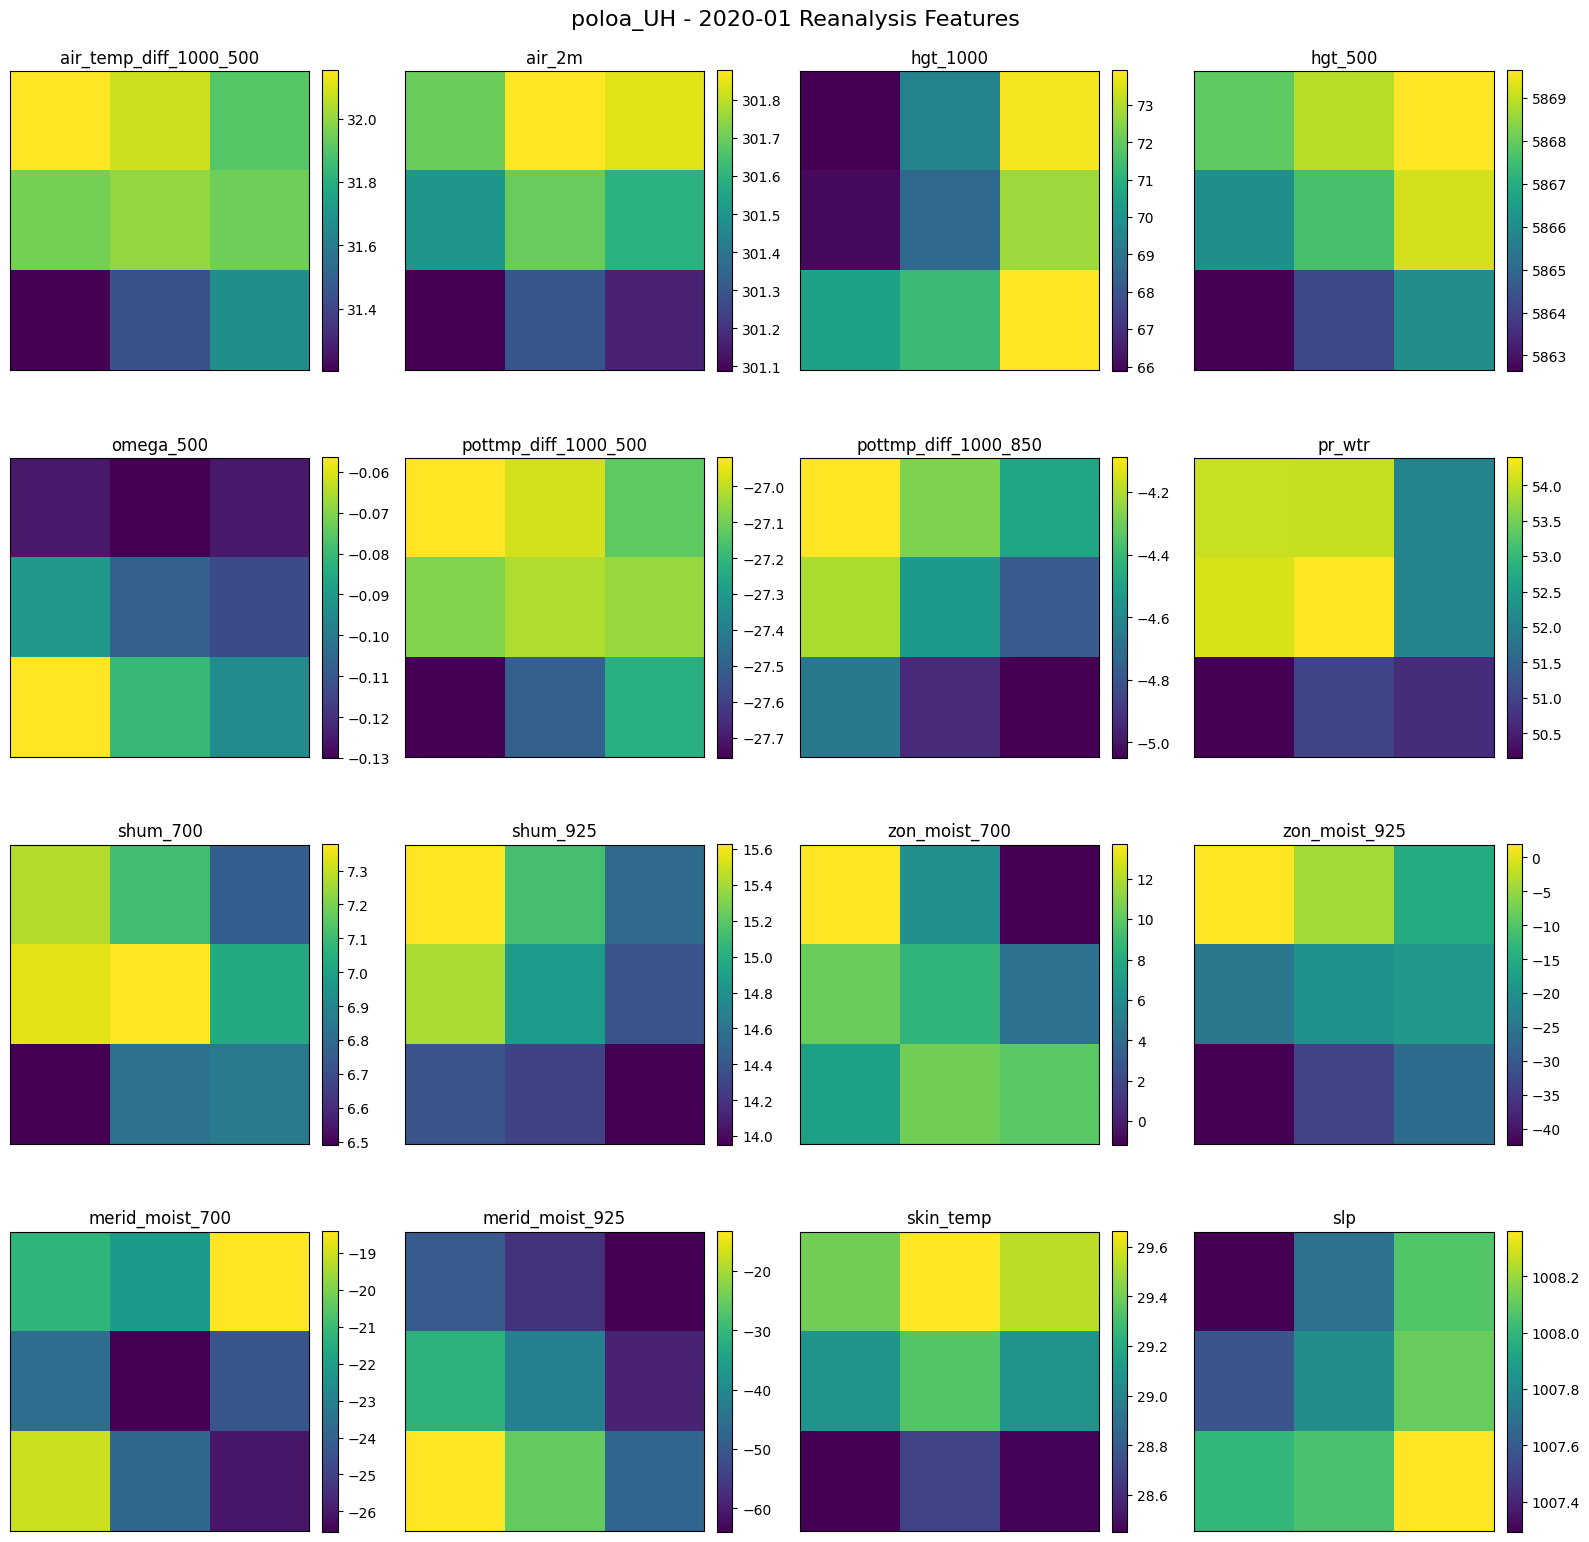

In [10]:
# Load aggregate NPZ
raw_reanalysis_npz = output_dir + "/reanalysis_npz/reanalysis_features_all.npz"

# Pick a target
station_name = "poloa_UH"
year, month = 2020, 1

viz_dir = output_dir + "/reanalysis_viz"
feature_builder.visualize_features_from_npz(raw_reanalysis_npz, station_name, year, month, output_dir=viz_dir)

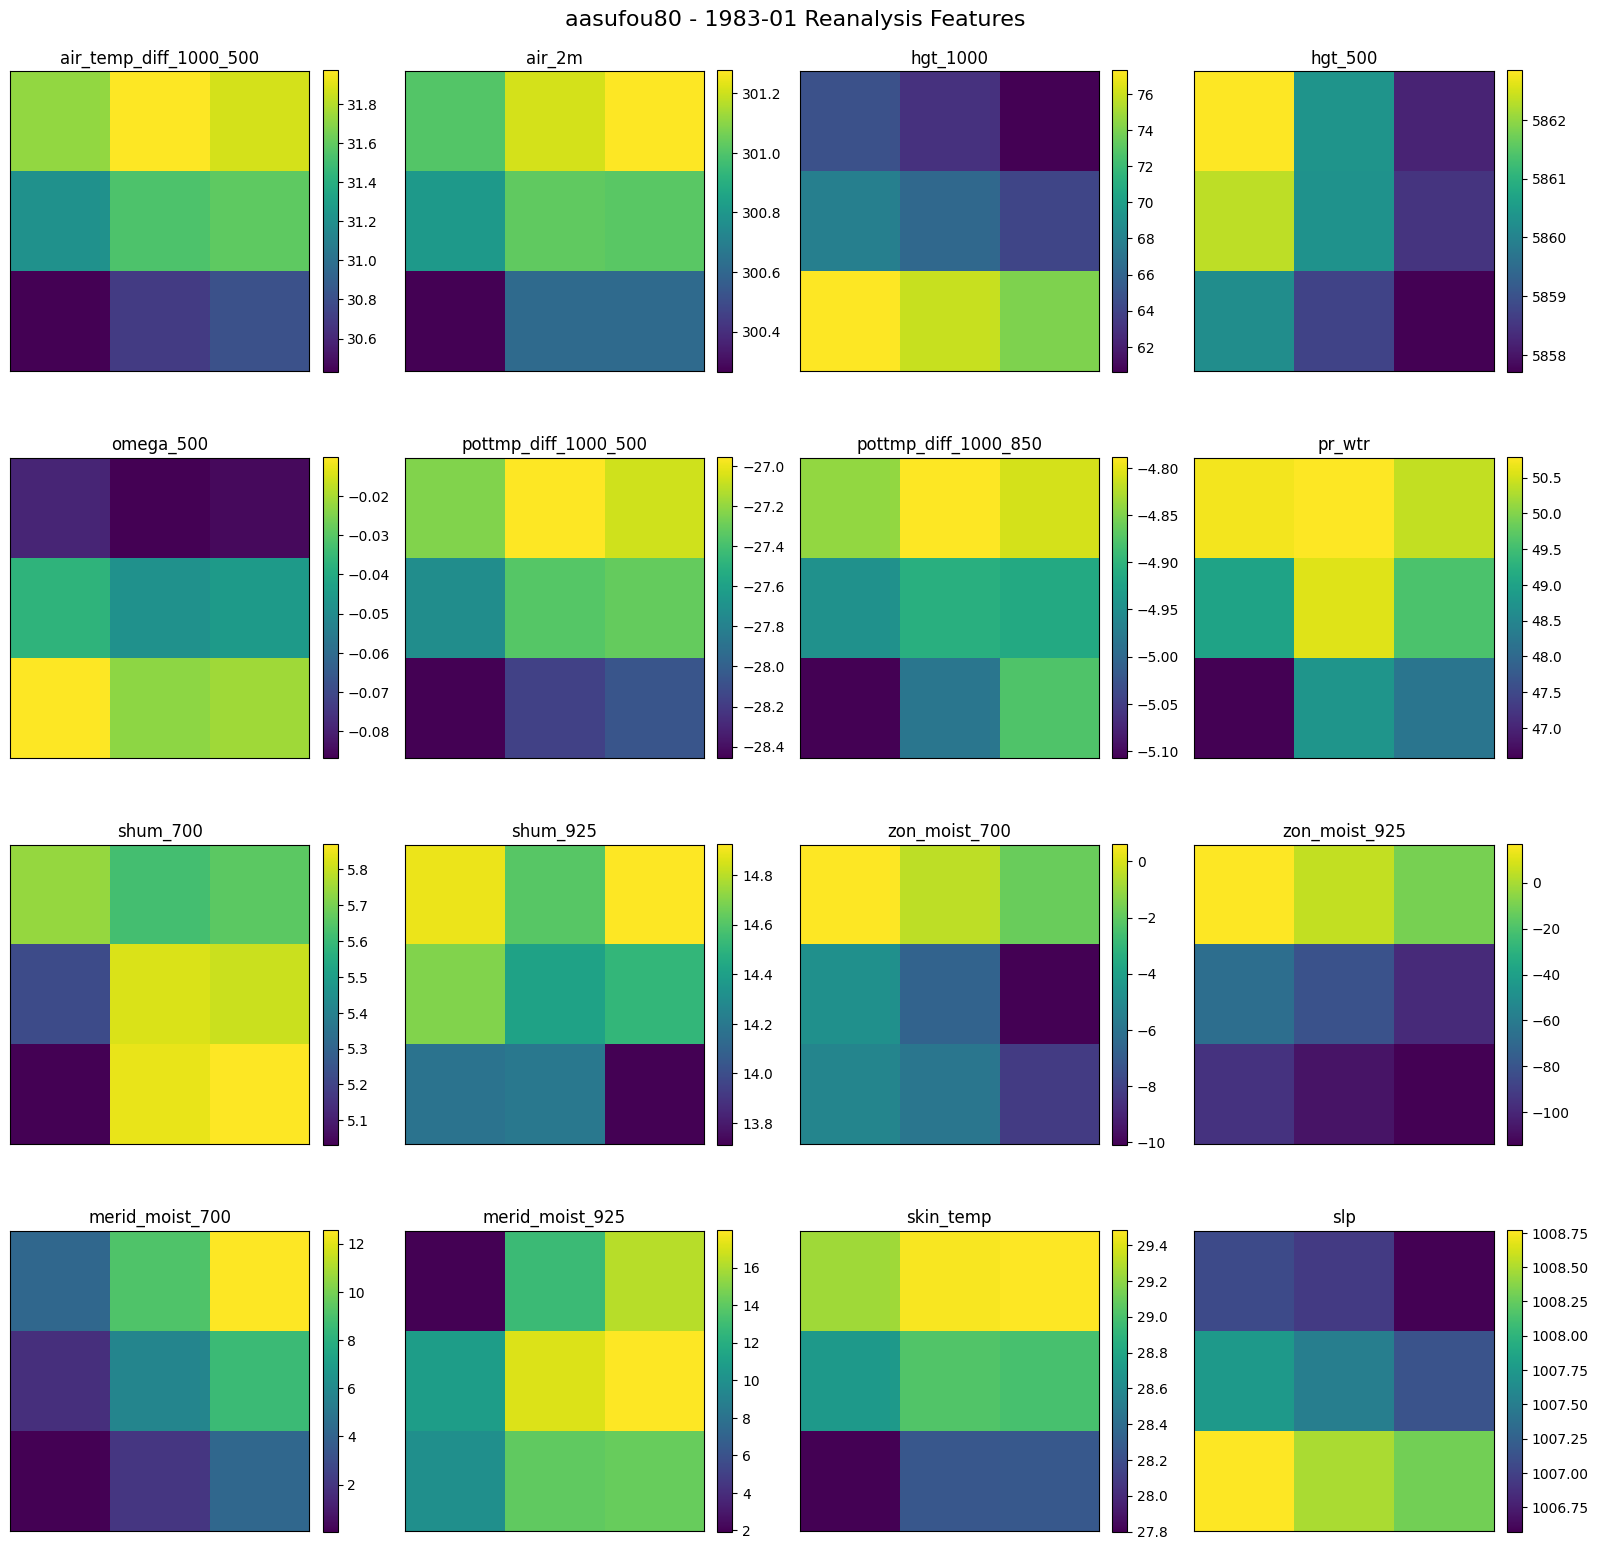

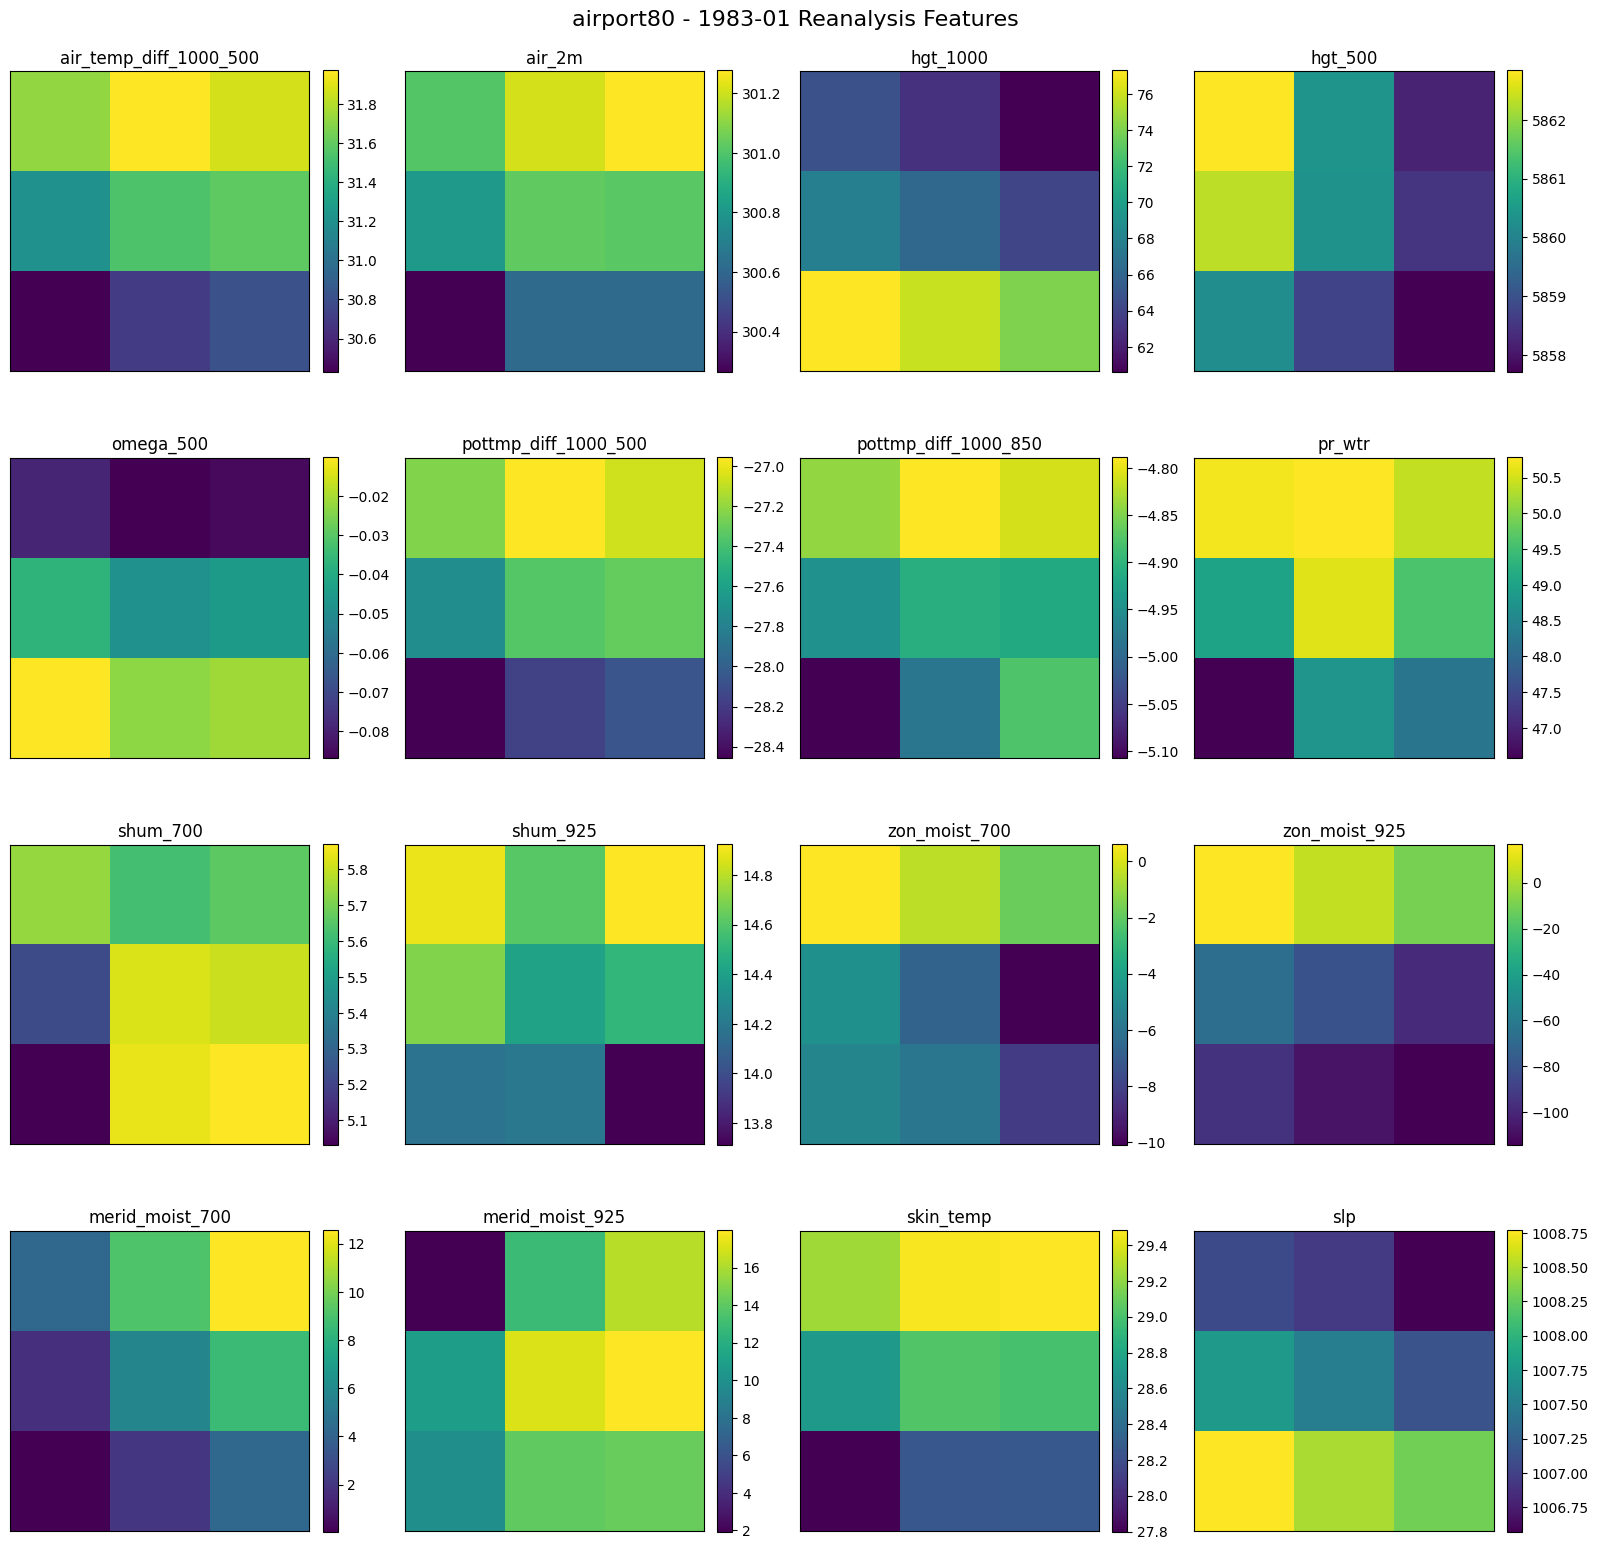

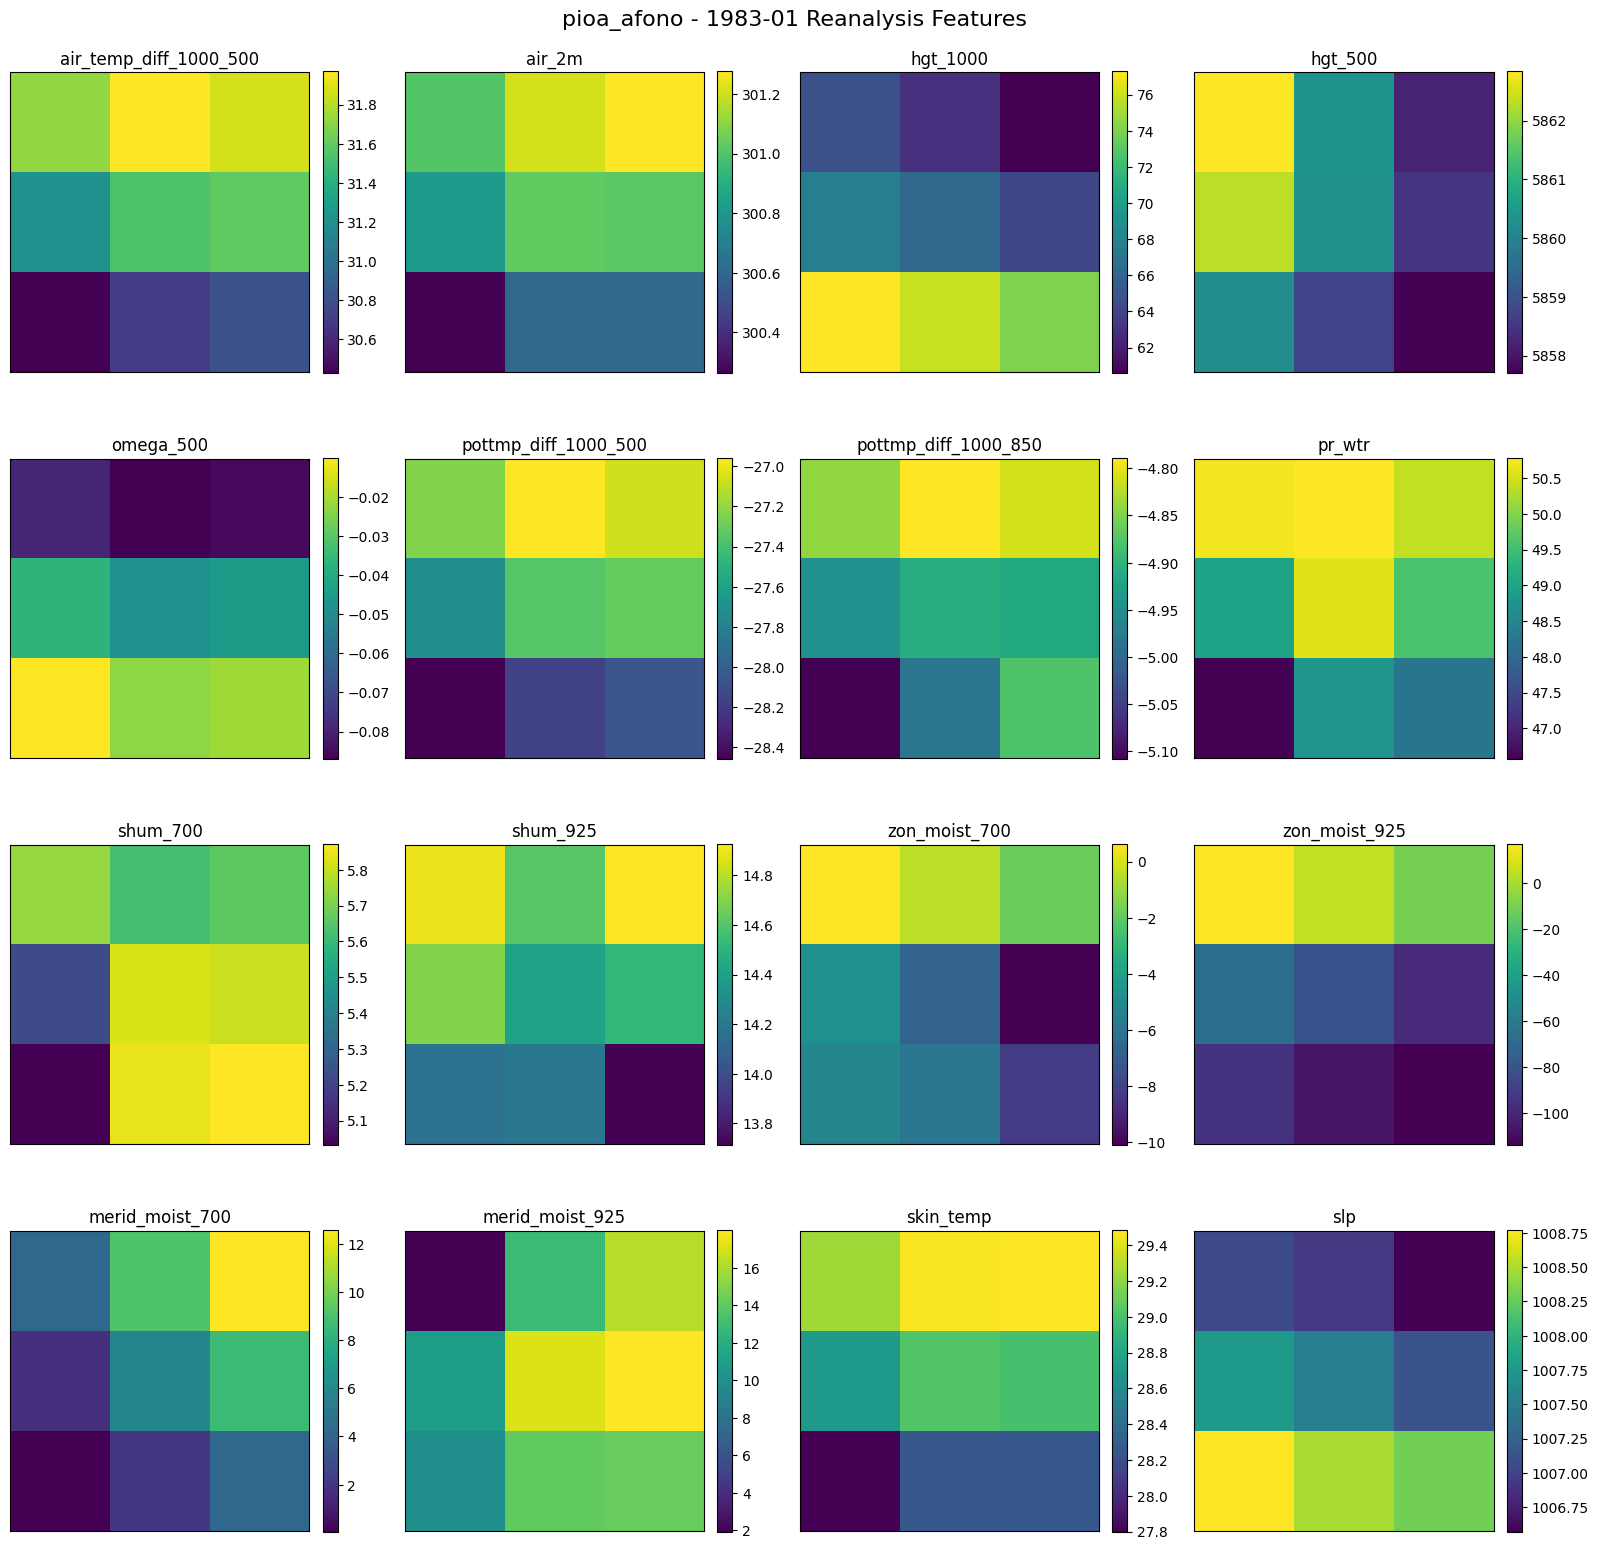

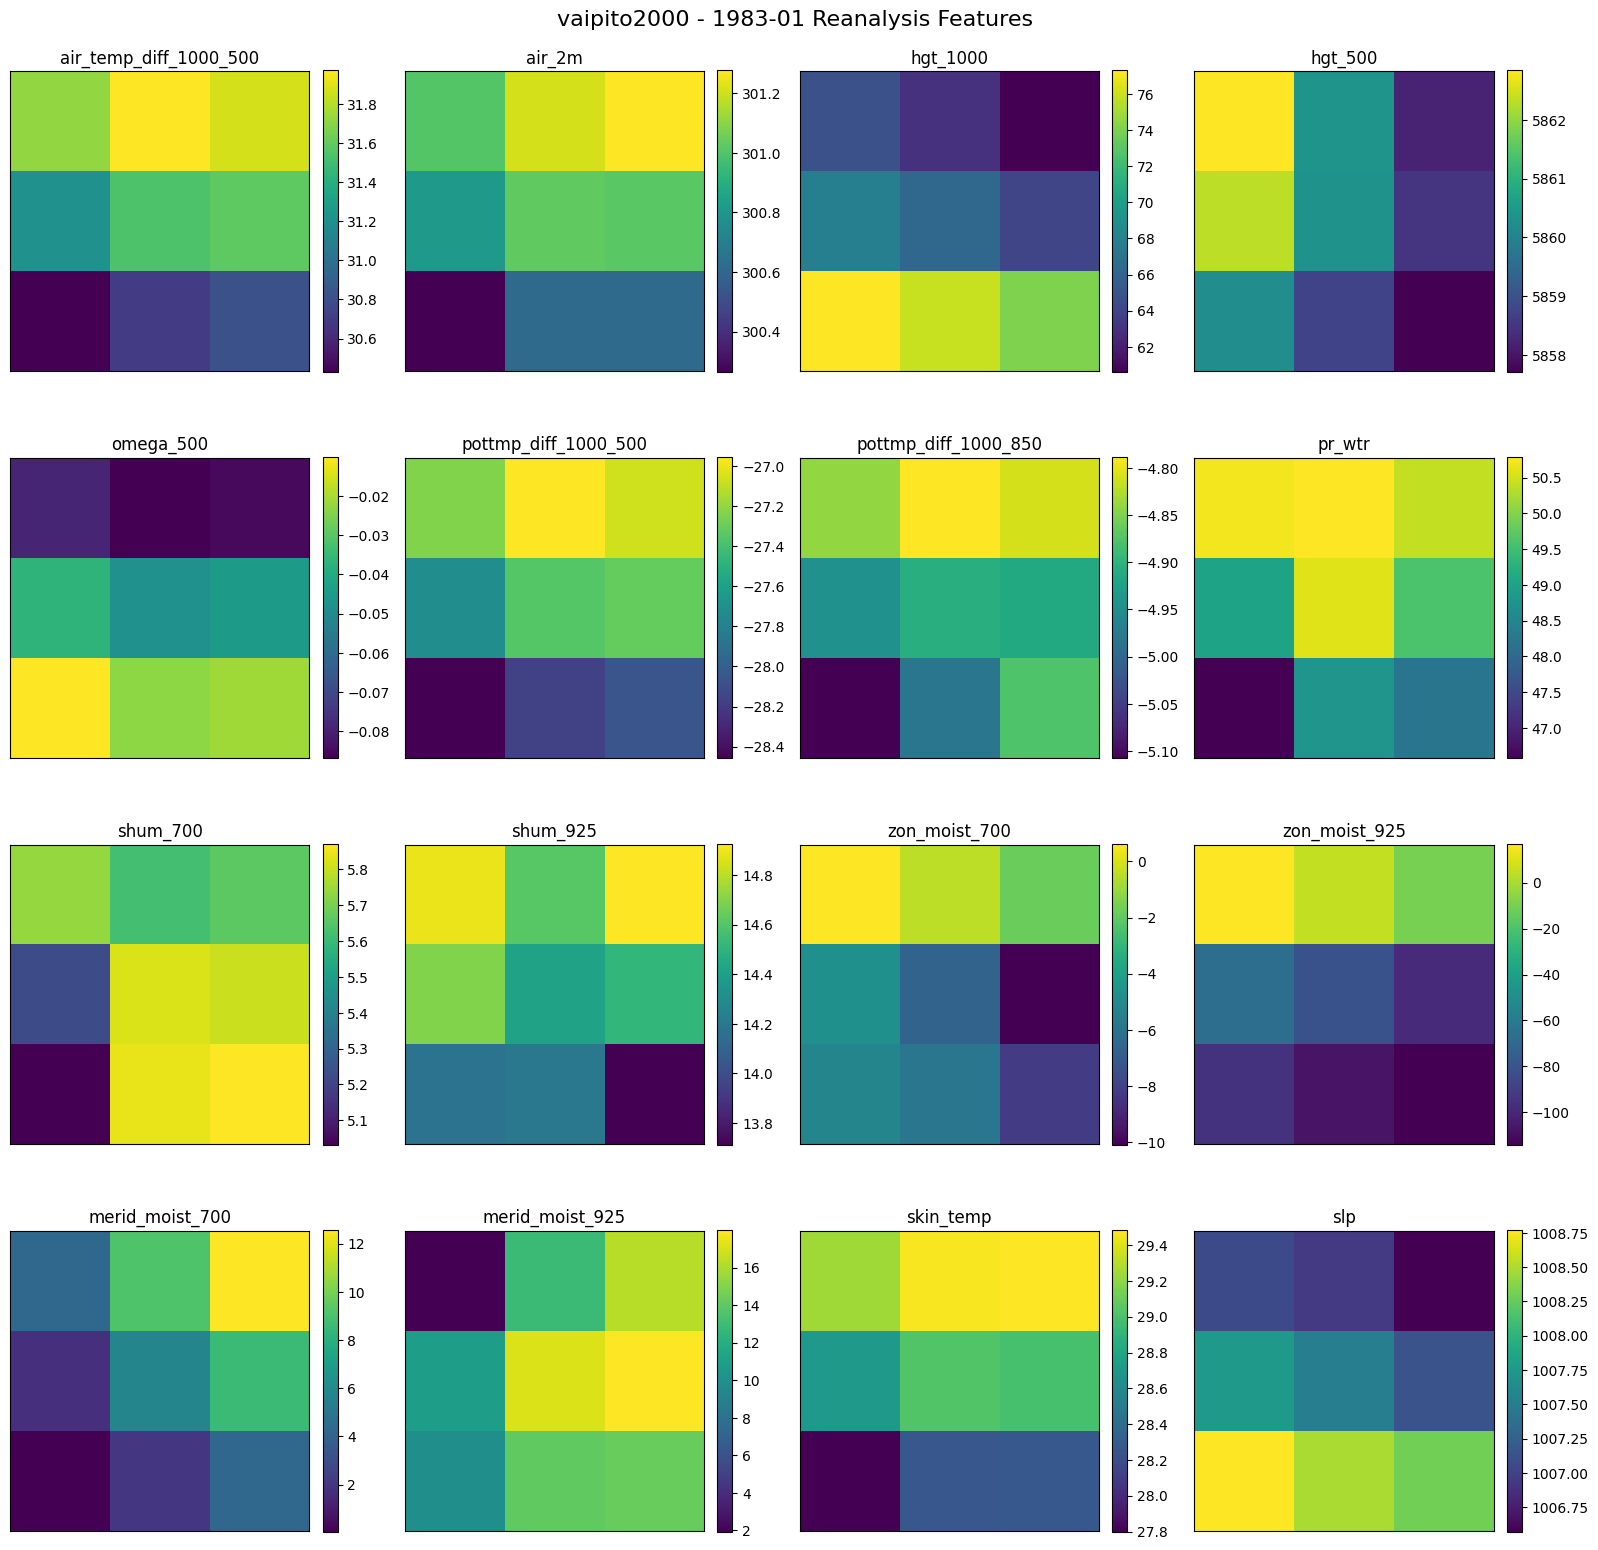

In [ ]:
# Checking different stations for same month-year
feature_builder.visualize_features_from_npz(raw_reanalysis_npz, 'aasufou80', 1983, 1, output_dir=viz_dir)
feature_builder.visualize_features_from_npz(raw_reanalysis_npz, 'airport80', 1983, 1, output_dir=viz_dir)
feature_builder.visualize_features_from_npz(raw_reanalysis_npz, 'pioa_afono', 1983, 1, output_dir=viz_dir)
feature_builder.visualize_features_from_npz(raw_reanalysis_npz, 'vaipito2000', 1983, 1, output_dir=viz_dir)


In [11]:
# Compute statistics and standardize patches
raw_features = np.load(raw_reanalysis_npz, allow_pickle=True)
stations = raw_features["stations"].astype(str)
years    = raw_features["years"].astype(int)
months   = raw_features["months"].astype(int)
patches  = raw_features["patches"]                # (N,V,H,W)
variables = [str(v) for v in raw_features["variables"].tolist()]

# Rebuild dict: {station: {(year, month): {var: patch}}}
features = {}
for i in range(patches.shape[0]):
    st, y, m = stations[i], int(years[i]), int(months[i])
    features.setdefault(st, {}).setdefault((y, m), {})
    for vi, var in enumerate(variables):
        features[st][(y, m)][var] = patches[i, vi]

# Compute statistics and standardize
variable_stats = feature_builder.compute_variable_statistics(features)
standardized_features = feature_builder.standardize_features(features, variable_stats)

standardized_features_filename = "reanalysis_features_all_standardized.npz"
if not os.path.exists(npz_dir + '/' + standardized_features_filename):
    feature_builder.export_all_features_npz(standardized_features, npz_dir, filename=standardized_features_filename)
    print(f"Saved standardized reanalysis NPZ to {std_path}")

air_temp_diff_1000_500 - Mean: 31.5339, Std: 1.0101
air_2m - Mean: 300.4841, Std: 0.8367
hgt_1000 - Mean: 96.5060, Std: 16.2105
hgt_500 - Mean: 5862.5288, Std: 12.0325
omega_500 - Mean: -0.0313, Std: 0.0314
pottmp_diff_1000_500 - Mean: -27.1578, Std: 1.0260
pottmp_diff_1000_850 - Mean: -4.5527, Std: 0.4866
pr_wtr - Mean: 42.6021, Std: 5.0642
shum_700 - Mean: 4.9073, Std: 1.2296
shum_925 - Mean: 13.2153, Std: 0.8711
zon_moist_700 - Mean: -7.0093, Std: 13.9971
zon_moist_925 - Mean: -64.7308, Std: 35.2045
merid_moist_700 - Mean: -3.3227, Std: 6.3706
merid_moist_925 - Mean: -7.4350, Std: 22.5096
skin_temp - Mean: 28.6240, Std: 0.8564
slp - Mean: 1010.9177, Std: 1.8565


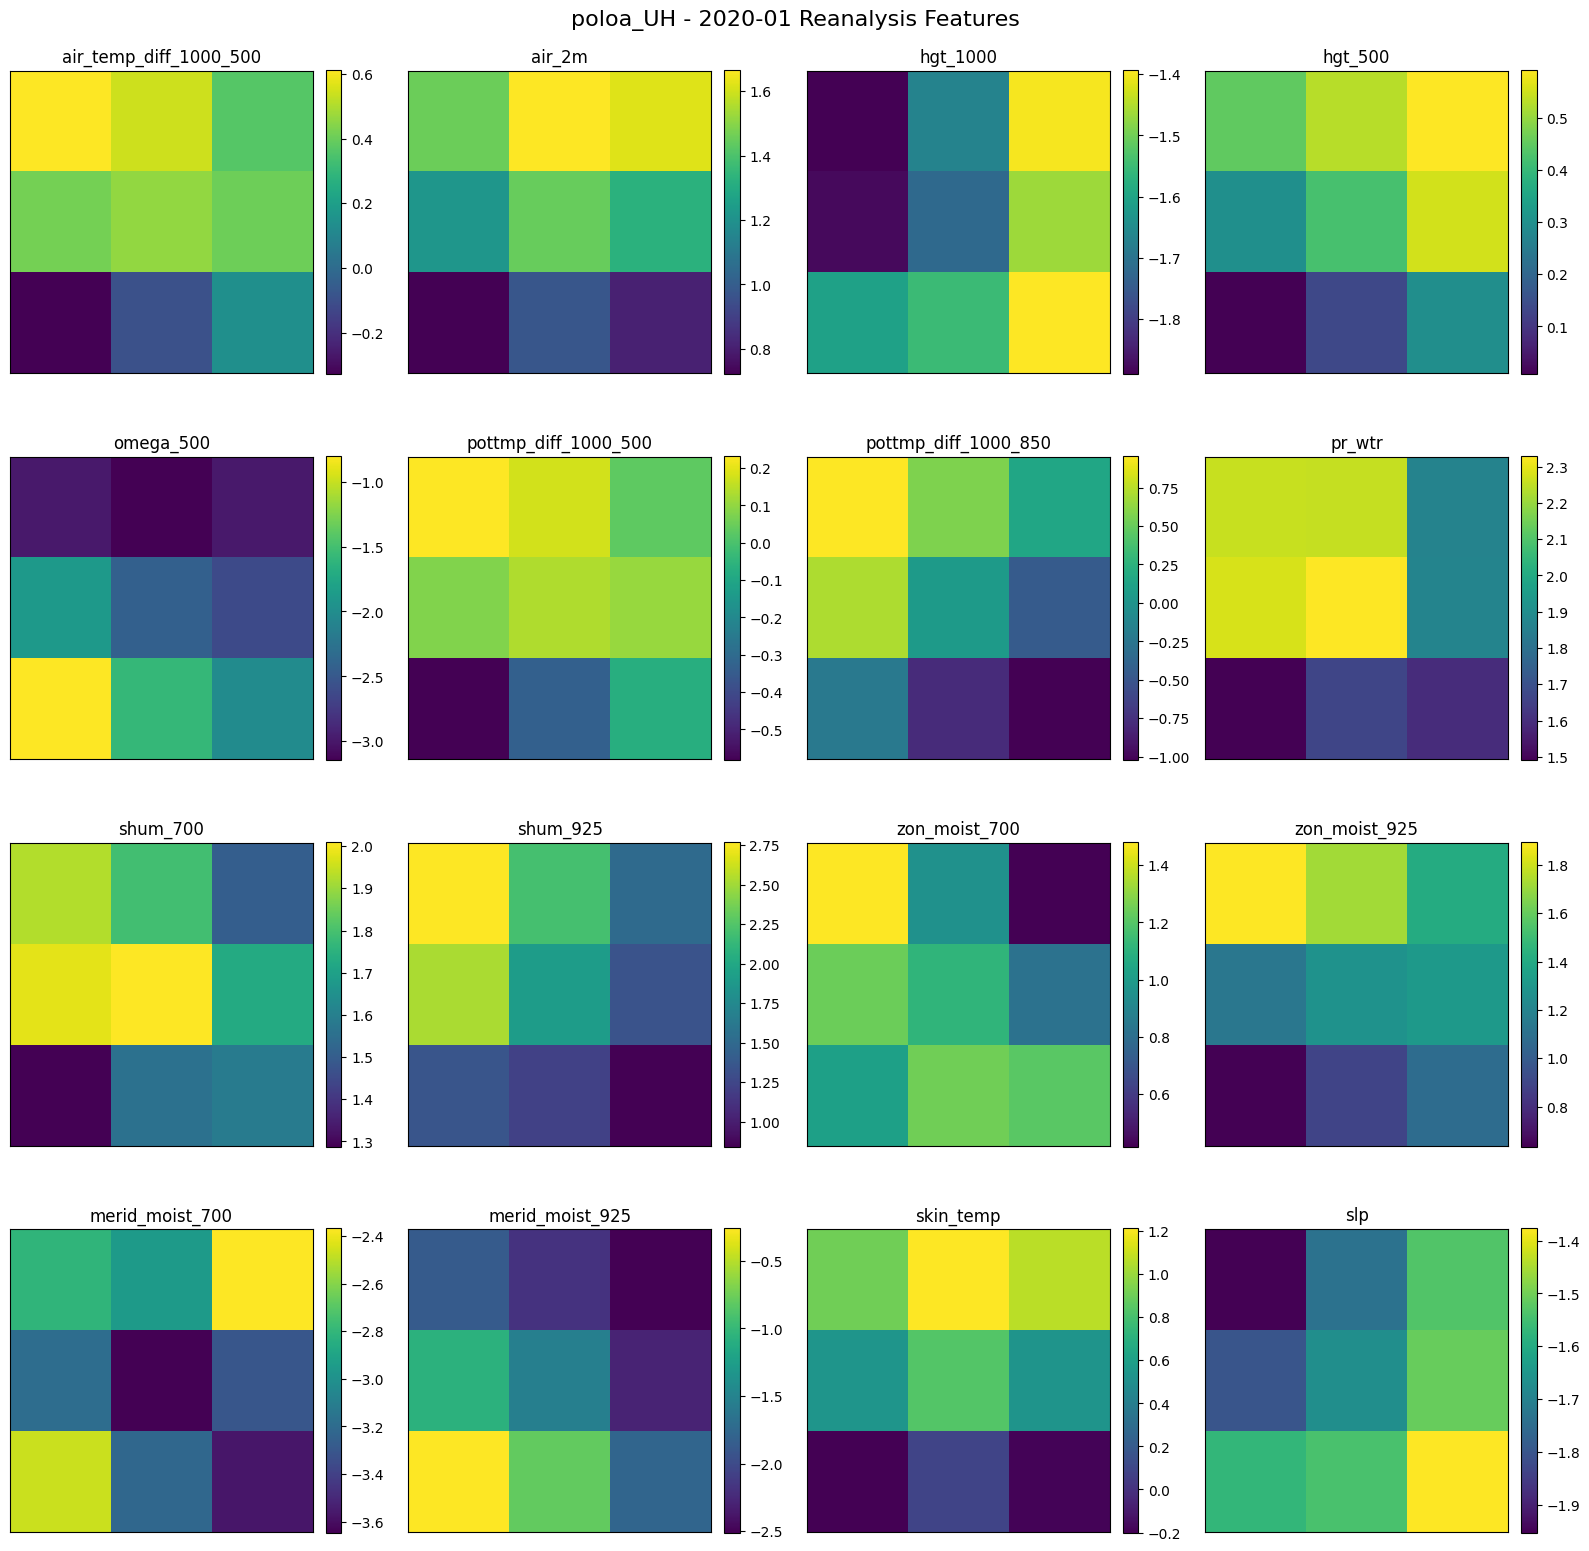

In [12]:
# Visualize standardized reanalysis features
standardized_reanalysis_path = output_dir + "/reanalysis_npz/reanalysis_features_all_standardized.npz"
feature_builder.visualize_features_from_npz(standardized_reanalysis_path, station_name, year, month, output_dir=viz_dir)

## 5. Assemble Training Data

This section demonstrates how to assemble training data by combining rainfall labels, one-hot encoded months, DEM patches, and reanalysis features.

In [13]:
# Default inputs produced by the DEM and Reanalysis builders
dem_npz_path = output_dir + "/dem_npz/dem_patches_all_standardized.npz"
re_npz_path  = output_dir + "/reanalysis_npz/reanalysis_features_all_standardized.npz"

# Output directory for the combined training NPZ
assembled_dir = output_dir + "/assembled_npz"
os.makedirs(assembled_dir, exist_ok=True)

assembler = TrainingDataAssembler()

full_training_data_path = assembler.assemble_from_precomputed(
    dem_npz_path=dem_npz_path,
    reanalysis_npz_path=re_npz_path,
    out_dir=assembled_dir,
    out_filename="full_training_data.npz",
)


Rainfall min: 0.0, max: 1076.197998046875
Saved full training NPZ to ML_Data_Preprocessing/output/assembled_npz/full_training_data.npz


In [14]:
def summarize_npz(npz_path):
    z = np.load(npz_path, allow_pickle=True)
    rows = []
    for k in z.files:
        arr = z[k]
        # Some entries might be scalars or 0-d arrays
        shape = getattr(arr, "shape", ())
        dtype = getattr(arr, "dtype", type(arr).__name__)
        size = getattr(arr, "size", 1)
        rows.append({"key": k, "shape": shape, "dtype": str(dtype), "size": int(size)})
    df = pd.DataFrame(rows).sort_values("key").reset_index(drop=True)
    return df
full_npz_path = output_dir + "/assembled_npz/full_training_data.npz"
npz_path = full_npz_path  # e.g., project_root / "ML_Data_Preprocessing/output/assembler/full_training_data.npz"
summ_df = summarize_npz(npz_path)
summ_df


,key,shape,dtype,size
0,dem_local_divstd,"(2032, 3, 3)",float32,18288
1,dem_local_max,(),float32,1
2,dem_local_min,(),float32,1
3,dem_local_minmax,"(2032, 3, 3)",float32,18288
4,dem_local_std,(),float32,1
5,dem_regional_divstd,"(2032, 3, 3)",float32,18288
6,dem_regional_max,(),float32,1
7,dem_regional_min,(),float32,1
8,dem_regional_minmax,"(2032, 3, 3)",float32,18288
9,dem_regional_std,(),float32,1
